# `reducnn` CIFAR-100 Research Suite (v0.6.6) 🔬

This notebook executes structural pruning experiments on the **CIFAR-100** dataset using the `reducnn` framework. It features **v0.6.6** capabilities including architecture-agnostic tracing, X-Ray visualization, and Hybrid Meta-Pruning.

## Notebook Guide
Recommended run order for presentation:
1. Bootloader and dataset setup
2. Baseline training and evaluation
3. Pruning run (produce `pruned_model` and `masks`)
4. Presentation Mode diagnostics section at the end


In [1]:
# --- STEP 0: GITHUB BOOTLOADER (v0.6.6 Colab Optimization) ---
import sys, os

# 1. Clone the repository from GitHub
repo_url = "https://github.com/albertraviss2023/activation-based-pruning.git"
repo_dir = "activation-based-pruning"

if not os.path.exists(repo_dir):
    print(f"🚀 Cloning {repo_url}...")
    !git clone {repo_url}
else:
    print(f"✅ Repository {repo_dir} already exists. Updating...")
    %cd {repo_dir}
    !git pull
    %cd ..

# 2. Environment Setup
os.chdir(repo_dir)
sys.path.insert(0, os.path.abspath("src"))

# 3. Install dependencies and editable package
!pip install -q --upgrade setuptools pip
!pip install -e .

# 4. Load autoreload and Verify

# --- Python 3.12 Compatibility Shim ---
import sys
try:
    import imp
except ImportError:
    from types import ModuleType
    import importlib
    imp = ModuleType('imp')
    imp.reload = importlib.reload
    sys.modules['imp'] = imp
    print("🛠️ Applied Python 3.12 'imp' shim")

%load_ext autoreload
%autoreload 2
import reducnn
print(f"\n✅ System Ready! ReduCNN v0.6.6 loaded from: {reducnn.__file__}")

🚀 Cloning https://github.com/albertraviss2023/activation-based-pruning.git...
Cloning into 'activation-based-pruning'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 183 (delta 4), reused 39 (delta 4), pack-reused 103 (from 1)
Receiving objects: 100% (183/183), 113.17 MiB | 37.82 MiB/s, done.
Resolving deltas: 100% (11/11), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
Obtaining file:///content/activation-based-pruning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements

In [2]:
import torch, torchvision, torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import reducnn as sp
import reducnn.visualization as viz
from reducnn.pruner import ReduCNNPruner
from reducnn.backends.torch_backend import PyTorchAdapter

# Local repository paths
checkpoint_dir = "my_models/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"📁 Local workspace initialized at: {os.getcwd()}")

📁 Local workspace initialized at: /content/activation-based-pruning


In [ ]:
# --- RUN ID + ARTIFACT PERSISTENCE (v0.88) ---
from pathlib import Path
from datetime import datetime
import os, re

def _slug(x):
    s = re.sub(r"\s+", "-", str(x or "").strip().lower())
    s = re.sub(r"[^a-z0-9_.-]", "", s)
    s = s.strip("-._")
    return s or "unknown"

DATASET_KEY = _slug(globals().get('DATASET_KEY') or globals().get('DATASET_NAME') or globals().get('dataset_name') or 'dataset')
MODEL_KEY = _slug(globals().get('MODEL_TYPE') or globals().get('model_type') or 'model')
RUN_ID = globals().get('RUN_ID') or f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_{DATASET_KEY}_{MODEL_KEY}"

OUTPUT_ARTIFACT_DIR = Path('outputs') / 'experiments' / DATASET_KEY / MODEL_KEY / RUN_ID
SAVED_ARTIFACT_DIR = Path('saved_models') / 'artifacts' / DATASET_KEY / MODEL_KEY / RUN_ID
OUTPUT_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
SAVED_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

os.environ['REDUCNN_RUN_ID'] = str(RUN_ID)
os.environ['REDUCNN_DATASET_KEY'] = str(DATASET_KEY)
os.environ['REDUCNN_ARTIFACT_DIR'] = str(OUTPUT_ARTIFACT_DIR)
os.environ['REDUCNN_ARTIFACT_MIRROR_DIR'] = str(SAVED_ARTIFACT_DIR)

print(f"Run ID: {RUN_ID}")
print(f"Artifacts: {OUTPUT_ARTIFACT_DIR}")
print(f"Artifacts mirror: {SAVED_ARTIFACT_DIR}")


In [ ]:
# --- Custom method registration (v0.88 unified: torch + keras) ---
from reducnn.pruner import register_method
import numpy as np

def _tools(kwargs):
    t = kwargs.get('tools', None)
    if t is None:
        raise ValueError('Backend tools not provided. Ensure adapter passes custom-method tools.')
    return t

def _max_batches(kwargs):
    val = kwargs.get('calib_batches', kwargs.get('prune_batches', kwargs.get('calibration_batches', None)))
    return int(val) if val else None

@register_method('custom_l2', framework='torch')
@register_method('custom_l2', framework='keras')
def custom_l2_score(layer, **kwargs):
    tools = _tools(kwargs)
    mode = str(kwargs.get('l2_mode', 'sum')).lower().strip()
    return np.asarray(tools.weight_l2(layer, mode=mode), dtype=np.float64).reshape(-1)

@register_method('chip', framework='torch')
@register_method('chip', framework='keras')
def chip_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return None
    max_spatial = kwargs.get('chip_max_spatial', None)
    return np.asarray(tools.chip_scores(A, max_spatial=max_spatial), dtype=np.float64).reshape(-1)

@register_method('custom_nisp', framework='torch')
@register_method('custom_nisp', framework='keras')
def custom_nisp_score(layer, **kwargs):
    tools = _tools(kwargs)
    lname = kwargs.get('layer_name', None)
    if lname is None:
        return np.asarray(tools.weight_l2(layer, mode='sum'), dtype=np.float64).reshape(-1)
    score_map = tools.nisp_score_map(max_batches=_max_batches(kwargs))
    s = score_map.get(lname, None)
    if s is None:
        return np.asarray(tools.weight_l2(layer, mode='sum'), dtype=np.float64).reshape(-1)
    return np.asarray(s, dtype=np.float64).reshape(-1)

@register_method('custom_spectral_energy', framework='torch')
@register_method('custom_spectral_energy', framework='keras')
def custom_spectral_energy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode='sum'), dtype=np.float64).reshape(-1)
    max_fft_samples = int(kwargs.get('max_fft_samples', 32))
    return np.asarray(tools.spectral_energy_scores(A, max_samples=max_fft_samples), dtype=np.float64).reshape(-1)

print('Custom methods registered: custom_l2, chip, custom_nisp, custom_spectral_energy (torch+keras).')


In [ ]:
# --- CSV artifact persistence helper (v0.88) ---
import os
import shutil
from pathlib import Path
import pandas as pd

def _artifact_root():
    out = globals().get('OUTPUT_ARTIFACT_DIR', None)
    if out is None:
        out = os.environ.get('REDUCNN_ARTIFACT_DIR', None)
    if out is None:
        out = Path('outputs') / 'experiments' / 'unknown'
    return Path(out)

def _artifact_mirror_root():
    mir = globals().get('SAVED_ARTIFACT_DIR', None)
    if mir is None:
        mir = os.environ.get('REDUCNN_ARTIFACT_MIRROR_DIR', None)
    return Path(mir) if mir else None

def _to_df(obj):
    if isinstance(obj, pd.DataFrame):
        return obj
    if isinstance(obj, list) and len(obj) > 0 and isinstance(obj[0], dict):
        return pd.DataFrame(obj)
    if isinstance(obj, dict):
        try:
            return pd.DataFrame(obj)
        except Exception:
            return pd.DataFrame([obj])
    return None

def persist_notebook_tables(namespace, prefix='results'):
    run_id = str(globals().get('RUN_ID', os.environ.get('REDUCNN_RUN_ID', 'run')))
    out_root = _artifact_root() / 'tables'
    out_root.mkdir(parents=True, exist_ok=True)
    mir_root = _artifact_mirror_root()
    if mir_root is not None:
        (mir_root / 'tables').mkdir(parents=True, exist_ok=True)

    saved = []
    key_tokens = ('result', 'summary', 'report', 'metric', 'table', 'record', 'comparison')
    for name, obj in namespace.items():
        lname = str(name).lower()
        if name.startswith('_'):
            continue
        if not any(t in lname for t in key_tokens):
            continue
        df = _to_df(obj)
        if df is None or df.empty:
            continue
        f = out_root / f'{run_id}_{prefix}_{name}.csv'
        df.to_csv(f, index=False)
        if mir_root is not None:
            mf = (mir_root / 'tables') / f.name
            shutil.copy2(f, mf)
        saved.append(str(f))
    return saved


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128)

print(f"✅ CIFAR-100 ready with {len(train_set)} training samples.")

100%|██████████| 169M/169M [00:05<00:00, 28.7MB/s] 


✅ CIFAR-100 ready with 50000 training samples.


🔥 Training VGG16 Baseline on CIFAR-100...


[VGG16_CIFAR100] Epoch 1/5: 100%|██████████| 391/391 [00:33<00:00, 11.70it/s, loss=3.9442, acc=3.76%]


📊 Validation: Loss 3.9553, Acc 5.84%


[VGG16_CIFAR100] Epoch 2/5: 100%|██████████| 391/391 [00:31<00:00, 12.26it/s, loss=3.2657, acc=9.78%]


📊 Validation: Loss 3.6224, Acc 11.45%


...

📊 Validation: Loss 3.1317, Acc 19.52%


[VGG16_CIFAR100] Epoch 4/5: 100%|██████████| 391/391 [00:32<00:00, 12.02it/s, loss=2.6779, acc=23.52%]


📊 Validation: Loss 2.9125, Acc 23.98%


[VGG16_CIFAR100] Epoch 5/5: 100%|██████████| 391/391 [00:32<00:00, 11.94it/s, loss=2.7586, acc=28.78%]


📊 Validation: Loss 2.6370, Acc 29.18%


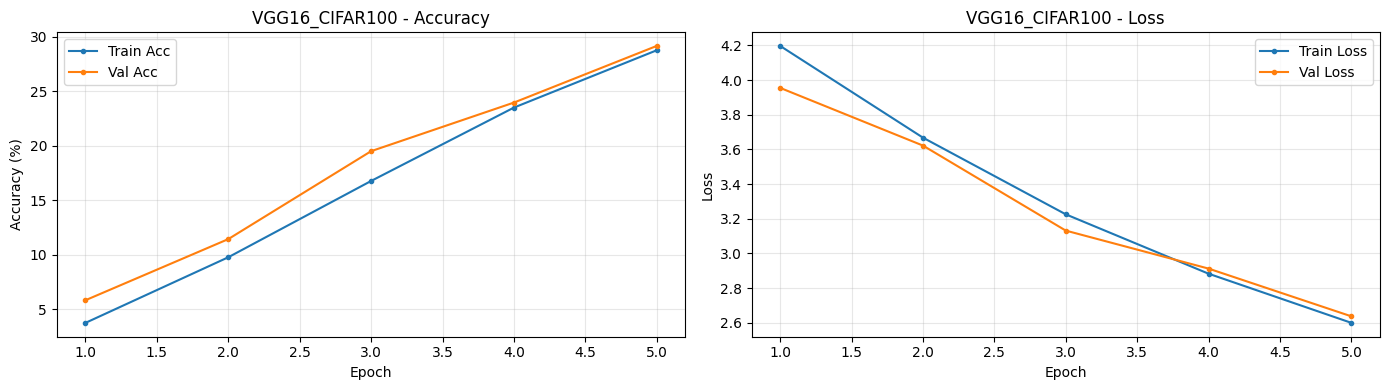

⏱️ train took 180.43s

✅ Baseline: 29.18%


In [4]:
adapter = PyTorchAdapter(config={'lr': 1e-3, 'input_shape': (3, 32, 32), 'num_classes': 100})
model = adapter.get_model("vgg16")

print("🔥 Training VGG16 Baseline on CIFAR-100...")
adapter.train(model, train_loader, epochs=5, name="VGG16_CIFAR100", val_loader=test_loader)
b_acc = adapter.evaluate(model, test_loader)
print(f"\n✅ Baseline: {b_acc:.2f}%")

🔬 PRUNING: L1-Norm (Local 30%)

--- Executing ReduCNN ---
🔍 Analyzing model using 'l1_norm' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
⏱️ prune took 0.10s
💊 Fine-tuning pruned model...


[Heal_L1_CIFAR100] Epoch 1/3: 100%|██████████| 391/391 [00:31<00:00, 12.31it/s, loss=2.2099, acc=33.18%]


📊 Validation: Loss 2.5692, Acc 31.91%


[Heal_L1_CIFAR100] Epoch 2/3: 100%|██████████| 391/391 [00:31<00:00, 12.40it/s, loss=2.4290, acc=38.84%]


📊 Validation: Loss 2.3148, Acc 36.88%


[Heal_L1_CIFAR100] Epoch 3/3: 100%|██████████| 391/391 [00:31<00:00, 12.55it/s, loss=2.0130, acc=43.31%]


📊 Validation: Loss 2.2974, Acc 37.80%


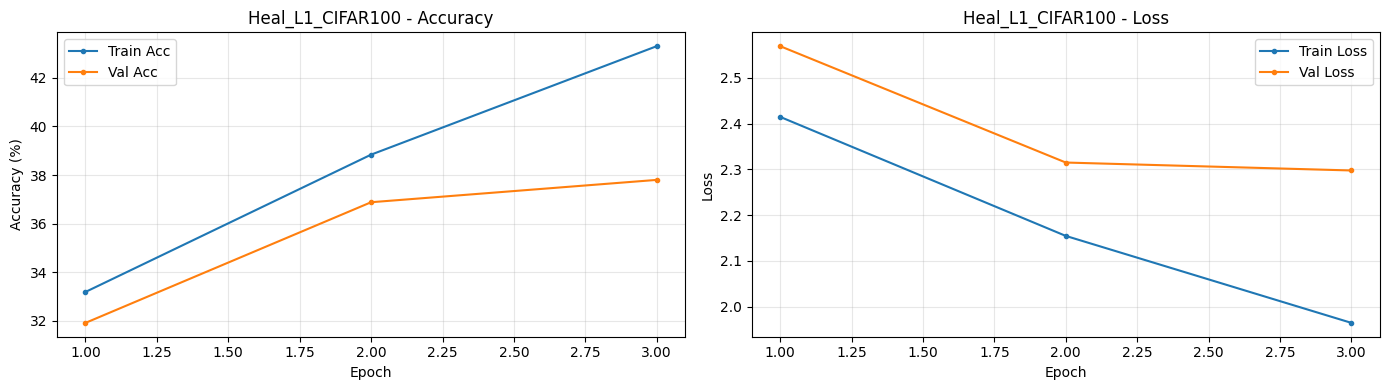

⏱️ train took 104.61s

✅ Pruned Accuracy: 37.80%


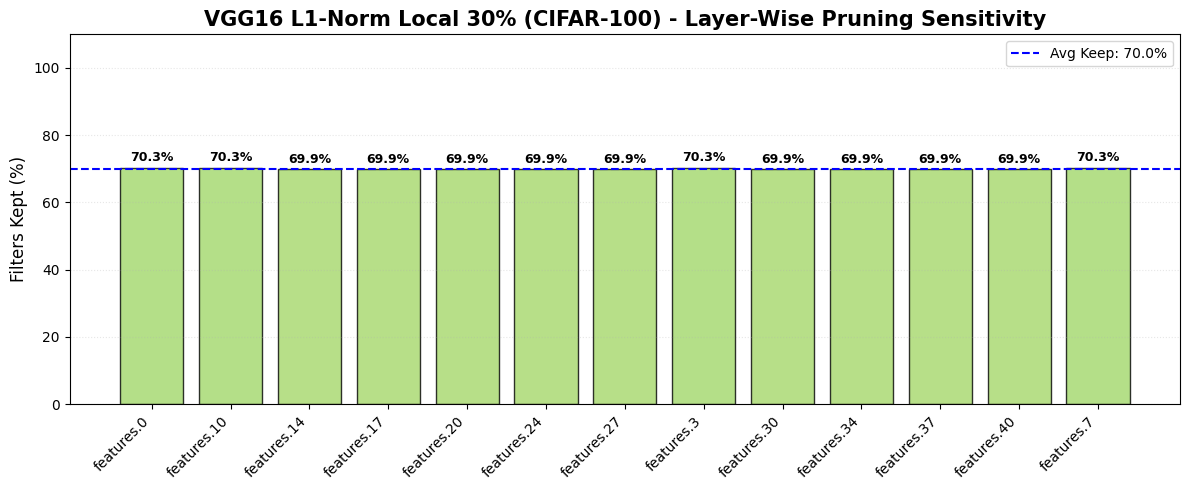

In [5]:
print("🔬 PRUNING: L1-Norm (Local 30%)")
surgeon = ReduCNNPruner(method='l1_norm', scope='local')
pruned_model, masks, duration = surgeon.prune(model, train_loader, ratio=0.3)

print("💊 Fine-tuning pruned model...")
adapter.train(pruned_model, train_loader, epochs=3, name="Heal_L1_CIFAR100", val_loader=test_loader)
p_acc = adapter.evaluate(pruned_model, test_loader)
print(f"\n✅ Pruned Accuracy: {p_acc:.2f}%")

viz.plot_layer_sensitivity(masks, "VGG16 L1-Norm Local 30% (CIFAR-100)")

## 🚀 Version 0.6.4: Advanced Tracing & X-Ray Visualization

ReduCNN v0.6.4 introduces **Architecture-Agnostic Tracing**. Instead of hardcoding layer paths, the framework uses dynamic graph analysis (`torch.fx` and Keras Functional API) to identify dependencies.

### 1. Pruning Clusters
When a model has residual connections (Add nodes), pruning one layer affects others. ReduCNN groups these into **Pruning Clusters** and ensures they share a unified pruning mask, maintaining structural integrity automatically.

### 2. X-Ray Visualization
The new `PruningAnimator` provides a "radar sweep" of the model to visualize these clusters and the physical "shrinkage" during surgery.

In [7]:
from reducnn.visualization.animator import PruningAnimator

print("🔦 Initializing X-Ray Visualizer...")
animator = PruningAnimator(adapter)

# Stage 1: Dependency Discovery
animator.show_dependency_sweep(model)

# Stage 3: Physical Shrink Simulation
animator.show_shrinkage(model, masks)
# Interactive Plotly X-Ray
fig = animator.generate_xray_animation(model, {}, masks)
fig.show()

ModuleNotFoundError: No module named 'reducnn.visualization.animator'

## 🧬 CHIP Method & Concatenative Surgery (DenseNet)

**CHIP (Channel Independence Pruning)** is a data-driven method that calculates filter importance based on the **matrix rank** of activations. High rank indicates unique information.

DenseNet represents "Class C" (Concatenative) architectures, where layers are merged via concatenation rather than addition. ReduCNN v0.6.4 handles this complex surgery by tracking channel offsets.

In [8]:
print("🧪 PYTORCH: DenseNet-121 + CHIP Pruning")
dense_model = adapter.get_model("densenet121", pretrained=True)

print("1. Performing CHIP-based Pruning (Local 10%)...")
dense_surgeon = ReduCNNPruner(method='chip', scope='local')
pruned_dn, dn_masks, _ = dense_surgeon.prune(dense_model, train_loader, ratio=0.1)

print(f"\n✅ DenseNet Surgery Complete.")
viz.plot_layer_sensitivity(dn_masks, "DenseNet-121 (CHIP) Sensitivity")

🧪 PYTORCH: DenseNet-121 + CHIP Pruning


TypeError: PyTorchAdapter.get_model() got an unexpected keyword argument 'pretrained'

## 🎨 Dual-Framework Support: Keras/TensorFlow Demo

ReduCNN is framework-agnostic. Here we demonstrate the same pruning workflow using the Keras backend.

In [9]:
from reducnn.backends.keras_backend import KerasAdapter
import tensorflow as tf

print("🛠️ Switching to Keras Backend...")
k_adapter = KerasAdapter(config={'lr': 1e-3, 'input_shape': (3, 32, 32), 'num_classes': 100})
k_model = k_adapter.get_model("vgg16")

print("🔬 KERAS PRUNING: L1-Norm (Local 20%)")
k_surgeon = ReduCNNPruner(method='l1_norm', scope='local')

k_pruned, k_masks, _ = k_surgeon.prune(k_model, train_loader, ratio=0.2)
print(f"\n✅ Keras Pruning Complete. Layers pruned: {len(k_masks)}")

🛠️ Switching to Keras Backend...
🔬 KERAS PRUNING: L1-Norm (Local 20%)

--- Executing ReduCNN ---
🔍 Analyzing model using 'l1_norm' method...
🏗️ Building masks (scope: local, ratio: 0.2)...
✂️ Applying physical surgery...
⏱️ prune took 0.48s

✅ Keras Pruning Complete. Layers pruned: 13


# Part D: Hybrid Meta-Pruning (Literature-Grounded) 

ReduCNN v0.6.6 introduces `method='hybrid'`, which combines activation sparsity with weight importance. This technique is grounded in SOTA literature for efficient neural network compression.

In [ ]:
print("🧪 HYBRID META-PRUNING (Literature-Grounded)")
hybrid_surgeon = ReduCNNPruner(method='hybrid', scope='global')
h_model, h_masks, _ = hybrid_surgeon.prune(model, train_loader, ratio=0.25)

print("\n🔥 Hybrid Heatmap Visualization...")
animator = PruningAnimator(adapter)
animator.generate_hybrid_heatmap(h_model).show()
_hyb_loader = globals().get("t_train", globals().get("train_loader", globals().get("loader", None)))
if _hyb_loader is not None:
    try:
        animator.generate_hybrid_contribution_graph(h_model, _hyb_loader).show()
    except Exception as e:
        print(f"Hybrid contribution graph skipped: {e}")


## Presentation Mode: Visual Diagnostics and Process Flow
This section is designed for demos and slides. It highlights:
1. Dependency graph and residual or concatenation clusters
2. Pruning candidate discovery (lowest-score channels)
3. Interactive X-ray graph walk (Discovery -> Importance -> Consistency -> Shrinkage)
4. Feature map visualization before and after pruning
5. Method agreement diagnostics (optional heavy step)


In [ ]:
# Presentation diagnostics utility (framework-agnostic, v0.6.6)
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import reducnn
import reducnn.visualization as viz
from reducnn.visualization.animator import PruningAnimator
from reducnn.analyzer.validator import MethodValidator

if tuple(map(int, reducnn.__version__.split('.'))) < (0, 6, 6):
    raise RuntimeError(f"Expected reducnn>=0.6.6, found {reducnn.__version__}")

def _resolve_from_globals(name_options):
    g = globals()
    for n in name_options:
        if n in g and g[n] is not None:
            return g[n], n
    return None, None

adapter, adapter_name = _resolve_from_globals(["adapter", "t_res_adapter", "k_adapter", "d_adapter", "dense_adapter"])
orig_model, model_name = _resolve_from_globals(["model", "t_res_model", "res_model", "dense_model", "d_model", "k_model"])
pruned_model, pruned_name = _resolve_from_globals(["pruned_model", "pruned_res", "h_model", "k_pruned", "pruned_dn", "d_pruned"])
masks, masks_name = _resolve_from_globals(["masks", "res_masks", "h_masks", "k_masks", "dn_masks", "d_masks"])
loader, loader_name = _resolve_from_globals(["test_loader", "train_loader", "loader", "val_loader", "t_test", "t_train", "k_test", "k_train"])

print(f"Resolved adapter: {adapter_name}")
print(f"Resolved original model: {model_name}")
print(f"Resolved pruned model: {pruned_name}")
print(f"Resolved masks: {masks_name}")
print(f"Resolved loader: {loader_name}")

if adapter is None or orig_model is None or loader is None:
    raise ValueError("Presentation diagnostics could not resolve adapter/model/loader. Run the main workflow first.")

if masks is None:
    masks = {}

score_method = "taylor"
try:
    score_map = adapter.get_score_map(orig_model, loader, score_method)
except Exception:
    score_method = "l1_norm"
    score_map = adapter.get_score_map(orig_model, loader, score_method)

print(f"Using score method for diagnostics: {score_method}")


In [ ]:
# 0) Optional: load a pre-trained checkpoint from repo/Drive path
# This enables prune-from-checkpoint workflows without baseline retraining.
LOAD_PRETRAINED_CHECKPOINT = False
PRETRAINED_CHECKPOINT_PATH = Path("my_models/pretrained_model.pth")  # Use .weights.h5 for Keras
if LOAD_PRETRAINED_CHECKPOINT:
    if PRETRAINED_CHECKPOINT_PATH.exists():
        adapter.load_checkpoint(orig_model, str(PRETRAINED_CHECKPOINT_PATH))
        print(f"Loaded pretrained checkpoint: {PRETRAINED_CHECKPOINT_PATH.resolve()}")
    else:
        print(f"Pretrained checkpoint not found: {PRETRAINED_CHECKPOINT_PATH}")

# 1) Trace graph and summarize dependency clusters
# Graph nodes = prunable conv nodes in the traced dependency graph.
# Clusters = residual add-linked layers that must share the same mask.
graph = adapter.trace_graph(orig_model)
clusters = graph.get("clusters", {})
print(f"Graph nodes: {len(graph.get('nodes', {}))}")
print(f"Pruning clusters: {len(clusters)}")
for cid, members in list(clusters.items())[:10]:
    print(f"  Cluster {cid}: {members[:8]}{' ...' if len(members) > 8 else ''}")

# 2) Build pruning candidate table (lowest-scoring channels per layer)
# candidate_count uses candidate_ratio (default 20% of each layer).
rows = []
candidate_ratio = 0.2
for layer_name, scores in score_map.items():
    s = np.asarray(scores, dtype=np.float64).reshape(-1)
    k = max(1, int(round(len(s) * candidate_ratio)))
    low_idx = np.argsort(s)[:k]
    rows.append({
        "layer": layer_name,
        "channels": len(s),
        "mean_score": float(np.mean(s)),
        "std_score": float(np.std(s)),
        "candidate_count": int(k),
        "candidate_indices": low_idx.tolist(),
    })

candidate_df = pd.DataFrame(rows).sort_values(["mean_score", "channels"], ascending=[True, False])
print("\nLowest-score candidate layers:")
display(candidate_df.head(20))

# 3) X-ray plotting pipeline
# show_dependency_sweep() prints Stage 1 cluster discovery text output.
# show_shrinkage() prints Stage 3 simulated channel shrink (orig -> kept).
# generate_xray_animation() plots a 4-frame graph: Discovery/Importance/Consistency/Shrink.
animator = PruningAnimator(adapter)
animator.show_dependency_sweep(orig_model)
if masks:
    animator.show_shrinkage(orig_model, masks)

fig = animator.generate_xray_animation(orig_model, score_map, masks)
animator.render(fig)

# 4) Feature map visualization before and after pruning
orig_viz = adapter.get_viz_data(orig_model, loader, num_layers=3)
viz.plot_feature_maps(orig_viz, title_prefix="Original Model")

if pruned_model is not None:
    try:
        pruned_viz = adapter.get_viz_data(pruned_model, loader, num_layers=3)
        viz.plot_feature_maps(pruned_viz, title_prefix="Pruned Model")
    except Exception as e:
        print(f"Skipped pruned feature maps: {e}")

# 5) Optional heavy method-agreement diagnostics
RUN_HEAVY_DIAGNOSTICS = False
if RUN_HEAVY_DIAGNOSTICS:
    methods = ["l1_norm", "apoz", "mean_abs_act"]
    MethodValidator().compare_methods(orig_model, loader, methods=methods, ratio=0.3)

# 6) Export artifacts + optional checkpoint persistence
import shutil

EXPORT_ARTIFACTS = True
SAVE_PRUNED_CHECKPOINT = True
SAVE_ORIGINAL_CHECKPOINT = False
COPY_TO_REPO_MODELS_DIR = True

export_dir = Path("exports")
repo_models_dir = Path("my_models")

def _default_ckpt_suffix(model_obj):
    t = str(type(model_obj)).lower()
    return ".weights.h5" if ("keras" in t or "tensorflow" in t) else ".pth"

def _save_ckpt(model_obj, stem_name):
    suffix = _default_ckpt_suffix(model_obj)
    out_path = export_dir / f"{stem_name}{suffix}"
    adapter.save_checkpoint(model_obj, str(out_path))
    print(f"Saved checkpoint: {out_path.resolve()}")
    if COPY_TO_REPO_MODELS_DIR:
        repo_models_dir.mkdir(parents=True, exist_ok=True)
        mirror_path = repo_models_dir / out_path.name
        shutil.copy2(out_path, mirror_path)
        print(f"Mirrored checkpoint: {mirror_path.resolve()}")

if EXPORT_ARTIFACTS:
    export_dir.mkdir(parents=True, exist_ok=True)
    candidate_path = export_dir / "pruning_candidates.csv"
    candidate_df.to_csv(candidate_path, index=False)

    if masks:
        masks_np = {k: np.asarray(v).astype(np.uint8) for k, v in masks.items()}
        np.savez_compressed(export_dir / "pruning_masks.npz", **masks_np)

    if SAVE_ORIGINAL_CHECKPOINT:
        _save_ckpt(orig_model, "original_model")
    if SAVE_PRUNED_CHECKPOINT and pruned_model is not None:
        _save_ckpt(pruned_model, "pruned_model")

    summary = {
        "version": reducnn.__version__,
        "score_method": score_method,
        "nodes": len(graph.get("nodes", {})),
        "clusters": len(clusters),
        "orig_stats": None,
        "pruned_stats": None,
    }
    try:
        summary["orig_stats"] = adapter.get_stats(orig_model, loader)
    except Exception:
        summary["orig_stats"] = adapter.get_stats(orig_model)
    if pruned_model is not None:
        try:
            summary["pruned_stats"] = adapter.get_stats(pruned_model, loader)
        except Exception:
            summary["pruned_stats"] = adapter.get_stats(pruned_model)

    with open(export_dir / "presentation_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, default=str)

    fig.write_html(str(export_dir / "presentation_pruning_xray.html"))
    print(f"Saved exports to: {export_dir.resolve()}")


In [ ]:
# --- Persist run tables to CSV artifacts (v0.88) ---
_saved_tables = persist_notebook_tables(locals(), prefix='run')
if _saved_tables:
    print('Saved CSV artifacts:')
    for _p in _saved_tables:
        print(' -', _p)
else:
    print('No matching tabular variables found for CSV export in this execution.')
